In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
loans = pd.read_csv("../data/loans_cleaned.csv")
defaults = pd.read_csv("../data/defaults_cleaned.csv")
branches = pd.read_csv("../data/branches_cleaned.csv")

In [3]:
loans['Interest_Income'] = (
    loans['Loan_Amount'] *
    loans['Interest_Rate'] / 100
)

In [4]:
total_interest_income = loans['Interest_Income'].sum()
total_interest_income

np.float64(24913672008.736)

In [5]:
term_profit = loans.groupby('Loan_Term')['Interest_Income'].sum()
term_profit.sort_values(ascending=False)

Loan_Term
60    5.031878e+09
36    5.012999e+09
48    4.998318e+09
24    4.975392e+09
12    4.895085e+09
Name: Interest_Income, dtype: float64

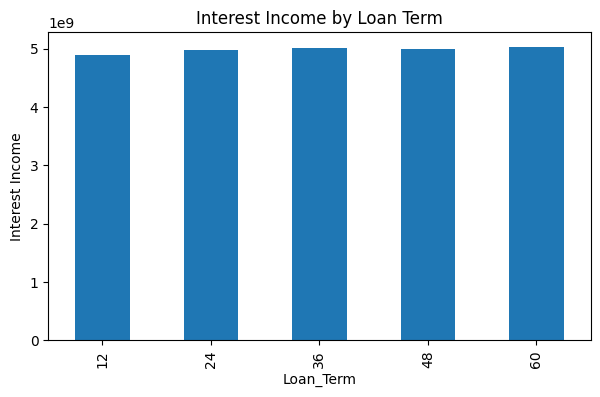

In [6]:
term_profit.plot(kind='bar', figsize=(7,4))
plt.title("Interest Income by Loan Term")
plt.ylabel("Interest Income")
plt.show()

In [7]:
loan_profit = loans.merge(
    defaults[['Loan_ID', 'Default_Amount']],
    on='Loan_ID',
    how='left'
)

loan_profit['Net_Income'] = loan_profit['Interest_Income'] - loan_profit['Default_Amount'].fillna(0)

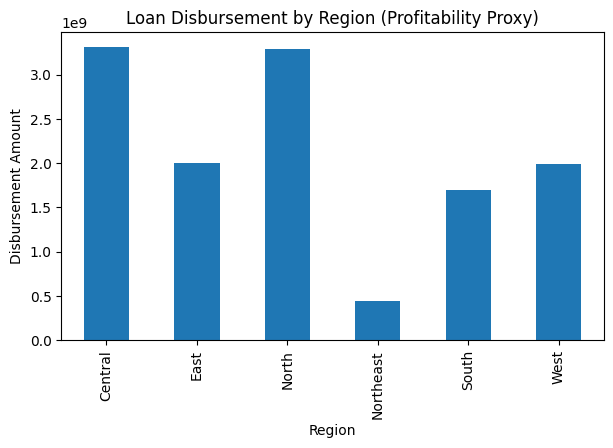

In [8]:
region_profit = branches.groupby('Region')['Loan_Disbursement_Amount'].sum()

region_profit.plot(kind='bar', figsize=(7,4))
plt.title("Loan Disbursement by Region (Profitability Proxy)")
plt.ylabel("Disbursement Amount")
plt.show()

### Task 12 – Profitability Insights

- Interest income is driven primarily by higher loan amounts and longer tenures
- Certain loan terms contribute disproportionately to total profitability
- Defaults significantly impact net profitability
- Regions with higher disbursement volumes generate greater interest income
- Incorporating risk-adjusted pricing can improve sustainable profitability